In [3]:
import sys, os
repo_root = r"C:\HocTap\UIT\CS416\Low-Light-Enhancement"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [4]:
import torch
import torch.nn as nn
from utils.dataset import get_loader
from utils.evaluation import evaluate_model, draw_images

In [6]:
root_dir = r"C:\HocTap\UIT\CS416\Low-Light-Enhancement\dataset"

mode = 'test'
test_loader = get_loader(root_dir, mode)


In [7]:
from models.gan import Generator
model = Generator()

In [9]:
state_dict = torch.load(
    r"C:\HocTap\UIT\CS416\Low-Light-Enhancement\checkpoints\GANs\Gen\generator_epoch_10.pth",
    map_location=torch.device('cpu')
)
model.load_state_dict(state_dict)


<All keys matched successfully>

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\HocTap\UIT\CS416\Low-Light-Enhancement\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\HocTap\UIT\CS416\Low-Light-Enhancement\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\HocTap\UIT\CS416\Low-Light-Enhancement\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]c:\HocTap\UIT\CS416\Low-Light-Enhancement\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `peak_signal_noise_ratio` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `peak_signal_noise_ratio` from `torchmetrics.image` instead.
  _future_warning(
c:\HocTap\UIT\CS416\Low-Light-Enhancement\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
Evaluating: 100%|██████████| 125/125 [01:58<00:00,  1.05it/s]


PSNR:  26.5021
SSIM:  0.9522
LPIPS: 0.0670


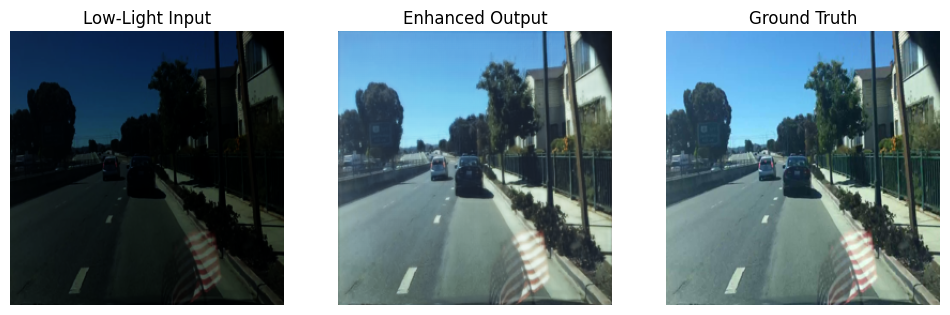

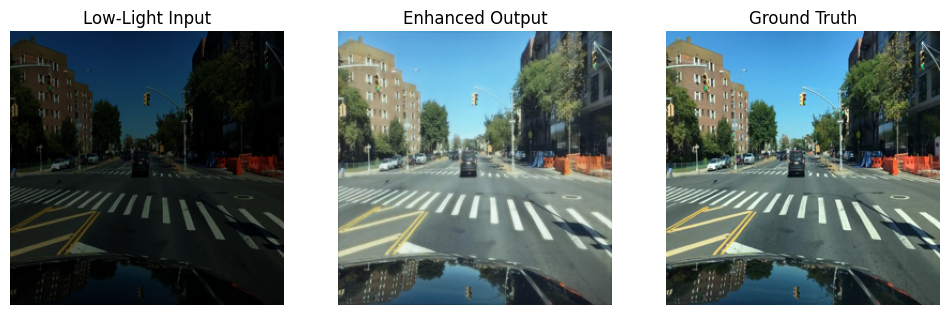

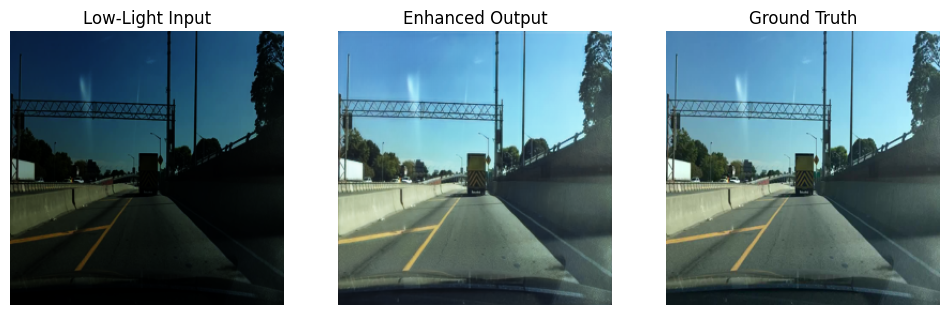

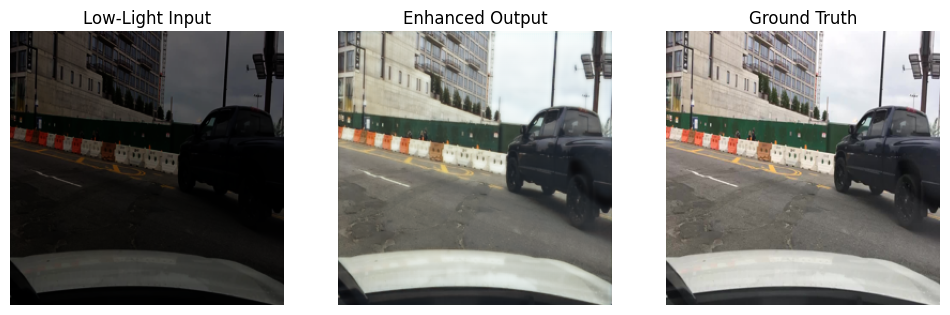

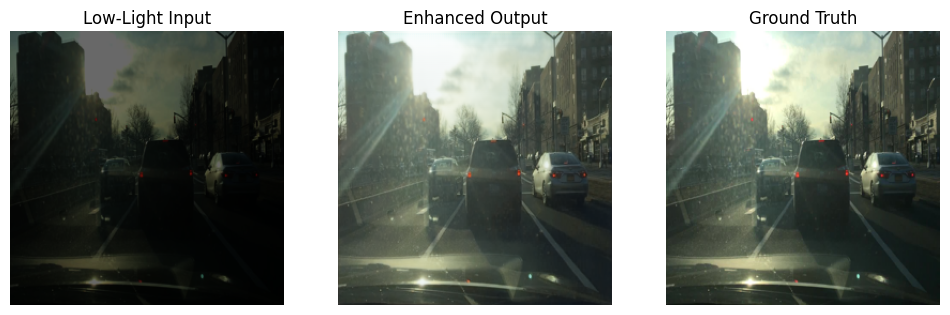

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evaluate_model(model, test_loader, device)

draw_images(model, test_loader, device, num_images=5)